### 순차 
- 텍스트 데이터 : ex) I am a boy. -> 순서가 의미가 있는 Data
- 시계열 데이터 : ex) 주식

### 순환 신경망(RNN : Recurrent Neural Network)

#### IMDB
- IMDB
- IMDB 구성 : Train Data(25,000개 중, 긍정 12,500 + 부정 12,500), Test Data(25,000개 중, 긍정 12,500 + 부정 12,500)
- NLP : Natural Language Process(자연어 처리)
- 말뭉치 : 하나의 데이터셋
- 토큰 : 하나의 단어를 의미
- 어휘사전 : 번호로 구분된 유일한 단어들의 집합

#### Keras로 IMDB 불러오기
: IMDB는 어휘 사전으로 변환되어 있다.

In [1]:
from tensorflow.keras.datasets import imdb

In [2]:
(train_input, train_target), (test_input, test_target) = \
    imdb.load_data(num_words=500) # 500개의 단어만 사용한다 -> imdb 데이터가 많기 때문

In [3]:
# Train과 Test 크기 확인
print(len(train_input), len(test_input))

25000 25000


In [4]:
# train의 첫 번째 문장의 Token 개수
len(train_input[0])

218

In [5]:
# train의 두 번째 문장의 Token 개수
len(train_input[1])

189

> 영화에 대한 댓글의 길이가 다르다

In [6]:
# 첫번째 댓글 출력
print(train_input[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 2, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


- 모든 샘플의 시작 부분의 토큰은 1을 사용한다
- 2는 선정한 단어 개수에 포함되지 않는 단어이다
- train_input의 자체는 numpy 배열이나 사용자마다 댓글에 사용한 토큰수가 다르기 때문에 numpy배열을 사용하지 못하고 python 의 list를 사용했다

In [7]:
# train 의 target 출력
print(train_target[:10])

[1 0 0 1 0 0 1 0 1 0]


---
#### 훈련세트 준비

In [8]:
from sklearn.model_selection import train_test_split

train_input, val_input, train_target, val_target = \
    train_test_split(
        train_input,
        train_target,
        test_size=0.2,
        random_state=42
    )

In [9]:
print(train_input.shape)
print(val_input.shape)
print(train_target.shape)
print(val_target.shape)

(20000,)
(5000,)
(20000,)
(5000,)


#### 각 리뷰마다 문자길이 시각화

In [10]:
import numpy as np

In [11]:
trainLength = []
for i in train_input:
    trainLength.append(len(i))

np.array(trainLength)

array([259, 520, 290, ..., 300,  70,  77], shape=(20000,))

In [12]:
# List Comprehension
totalLength = np.array([len(i) for i in train_input ])
totalLength

array([259, 520, 290, ..., 300,  70,  77], shape=(20000,))

---
##### List Comprehension Exercise

In [13]:
# 0 부터 9 까지의 숫자중 짝수만 List에 추가
even = [x for x in range(1, 10) if x % 2 == 0]
even

[2, 4, 6, 8]

In [14]:
# 평균과 중앙값
print(np.mean(trainLength), np.median(trainLength))

239.00925 178.0


> 중앙값보다 평균이 크므로 예상치 않게 길게 달린 댓글이 있다고 추측할 수 있다.

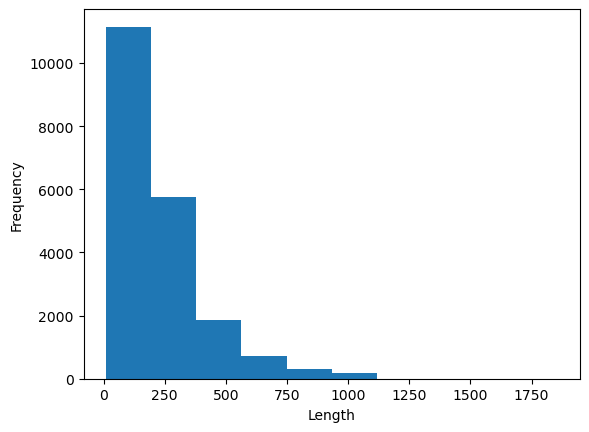

In [15]:
import matplotlib.pyplot as plt

plt.hist(trainLength) # 히스토그램 = 빈도수 확인하는 그래프
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

---
#### Sequence Padding
: 전체 자릿수를 100으로 가정했을 경우 한 문장의 토큰이 3개 있을 경우 97개는 0으로 채운다.

In [16]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [17]:
# 크기 확인
print(train_seq.shape, val_seq.shape)

(20000, 100) (5000, 100)


In [19]:
# 천번째 댓글 확인
print(train_seq[5])

[  0   0   0   0   1   2 195  19  49   2   2 190   4   2 352   2 183  10
  10  13  82  79   4   2  36  71 269   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14 238  56 129   2  10  10  21   2  94 364 352   2   2  11 190
  24 484   2   7  94 205 405  10  10  87   2  34  49   2   7   2   2   2
   2   2 290   2  46  48  64  18   4   2]


---
#### 순환 신경망 모델 만들기

In [20]:
train_seq.shape

(20000, 100)

In [21]:
# One-hot Encoding
from tensorflow import keras

train_oh = keras.utils.to_categorical(train_seq)
print(train_oh.shape)

(20000, 100, 500)


In [22]:
train_oh[1]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]], shape=(100, 500))

In [24]:
model = keras.Sequential()
model.add(
    keras.layers.SimpleRNN(
        8,
        input_shape=(100, 500)
    )
)

model.add(
    keras.layers.Dense(
        1,
        activation='sigmoid'
    )
)

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [25]:
# 검증 세트도 one hot encoding
val_oh = keras.utils.to_categorical(val_seq)

In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         4,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,081 (15.94 KB)

 Trainable params: 4,081 (15.94 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Loss & Learning Rate
model.compile(
    optimizer = 'rmsprop',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [30]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('../Data/best_simplernn.keras')
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True
)

In [31]:
history = model.fit(
    train_oh,
    train_target,
    epochs=40,
    batch_size=64,
    validation_data = (val_oh, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.5167 - loss: 0.6927 - val_accuracy: 0.5404 - val_loss: 0.6881
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5736 - loss: 0.6798 - val_accuracy: 0.5592 - val_loss: 0.6782
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6510 - loss: 0.6311 - val_accuracy: 0.7026 - val_loss: 0.5913
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7216 - loss: 0.5588 - val_accuracy: 0.7092 - val_loss: 0.5732
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7520 - loss: 0.5189 - val_accuracy: 0.7382 - val_loss: 0.5392
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7732 - loss: 0.4907 - val_accuracy: 0.7250 - val_loss: 0.5510
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7847 - loss: 0.4724 - val_accuracy: 0.7674 - val_loss: 0.4974
Epoch 8/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7955 - loss: 0.4531 - val_acc

> 전체 댓글의 토큰중 100개만 학습하였더니 80% 이상의 예측력을 보였다.|

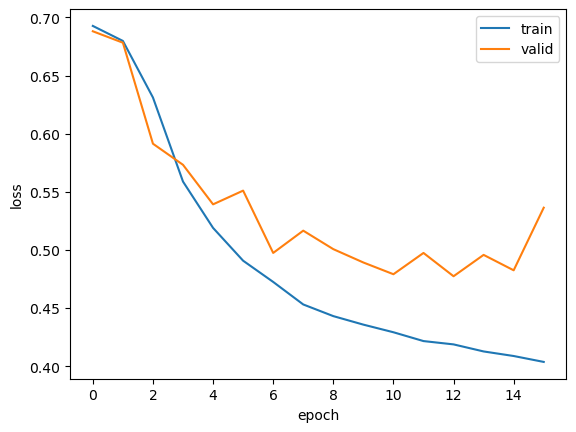

In [32]:
# 시각화 해보기
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

In [33]:
# 평가하기
model.evaluate(train_oh, train_target)

625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8299 - loss: 0.3944


[0.3944319188594818, 0.8298500180244446]

In [34]:
# 평가하기
model.evaluate(val_oh, val_target)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7820 - loss: 0.4773


[0.4773363173007965, 0.7820000052452087]

> 짧은 자연어 문장은 RNN 이 가장 잘 맞춤. 장문의 글은 Transformer 모델 앞도적.

---
#### LSTM(Long Short Term Memory)